In [1]:
import utils
import pretty_midi
import yaml
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt 

from config import load_config
from dataset import PreparedSubject, TRFDataset


(79891,)


Text(0.5, 1.0, 'Raw EEG of Sub2 and Trial 1')

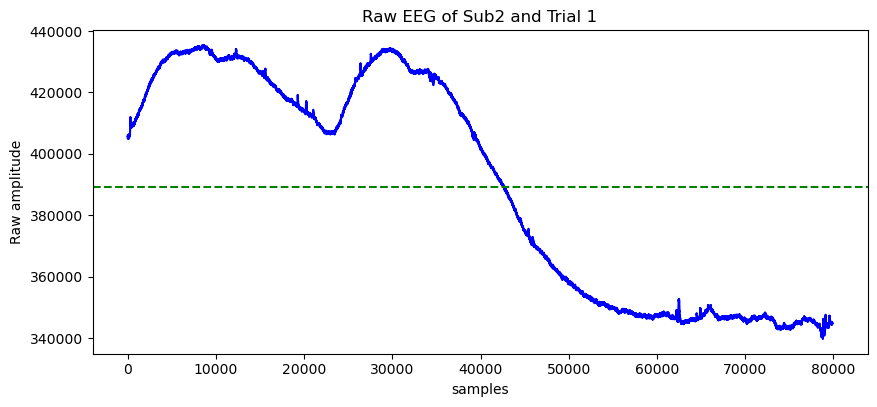

In [11]:
from scipy.io import loadmat

config = load_config()
subject = 'Sub2'
trial = 1
channel = 0
duration = 2
eeg_path = config.paths.eeg_dir / config.eeg_filename_pattern.format(subject=subject)

mat_data = loadmat(eeg_path, struct_as_record=False, squeeze_me=True)
eeg = mat_data["eeg"]
orig_fs = int(eeg.fs)
start_idx = orig_fs*duration
ex_eeg = eeg.data[trial][:,channel]
print(ex_eeg.shape)
avg_amplitude = np.abs(ex_eeg).mean()

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(ex_eeg[:], color='blue')
ax.axhline(
    avg_amplitude,
    color='green',
    linestyle='--',
    label='Mean absolute amplitude'
)
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw EEG of {subject} and Trial {trial}")


In [12]:
eeg_data = {
    'trials': eeg.data,
    'fs': orig_fs,                              # original fs; no resampling done
    'pad_start': int(eeg.paddingStartSample),    # in original-fs samples
}

# 1. per-trial LPF -> downsample -> HPF -> strip padding
preprocessed_trials = utils.preprocess_eeg_trials(
    eeg_data, target_fs=config.sfreq,
    lpf_hz=config.high_frequency, hpf_hz=config.low_frequency)



Text(0.5, 1.0, 'Raw EEG of Sub2 and Trial 1')

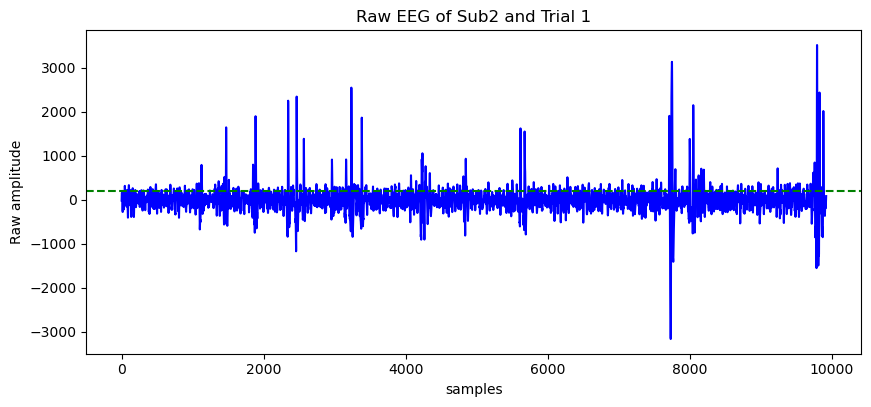

In [13]:
ex_processed_eeg = preprocessed_trials[trial][:,channel]
avg_processed_amplitude = np.abs(ex_processed_eeg).mean()

new_start_idx=config.sfreq*2

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(ex_processed_eeg[:], color='blue')
ax.axhline(
    avg_processed_amplitude,
    color='green',
    linestyle='--',
    label='Mean absolute amplitude')
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw EEG of {subject} and Trial {trial}")


In [14]:
config = load_config()
subject = 'Sub2'
eeg_path = config.paths.eeg_dir / config.eeg_filename_pattern.format(subject=subject)
eeg_data = utils.load_subject_raw_eeg(eeg_path, subject)

acoustic_ds = TRFDataset(
    subject, 
    eeg_data, 
    'acoustic',
    config, 
    window_samples=7*64,
    hop_samples=6*64
    )

acoustic_and_surprisal_ds = TRFDataset(
    subject, 
    eeg_data, 
    'acoustic_and_surprisal',
    config, 
    window_samples=7*64,
    hop_samples=6*64
    )

prepared = PreparedSubject(subject, eeg_data, config, debug=True)

✓ Loaded raw EEG (Sub2): 30 trials, 64 channels @ 512 Hz
  [pre] Trial 1: raw = 82395 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 1: post-preproc = 10236 samples @ 64 Hz
  [pre] Trial 2: raw = 79891 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 2: post-preproc = 9923 samples @ 64 Hz
  [pre] Trial 3: raw = 62544 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 3: post-preproc = 7754 samples @ 64 Hz
  [pre] Trial 4: raw = 70553 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 4: post-preproc = 8756 samples @ 64 Hz
  [pre] Trial 5: raw = 85879 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 5: post-preproc = 10671 samples @ 64 Hz
  [pre] Trial 6: raw = 103070 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 6: post-preproc = 12820 samples @ 64 Hz
  [pre] Trial 7: raw = 89690 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 7: post-preproc = 11148 samples @ 64 Hz
  [pre] Trial 8: raw = 94316 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 8: post-preproc =

Text(0.5, 1.0, 'Raw onset_entropy of stimulus for Sub2 in Trial 1')

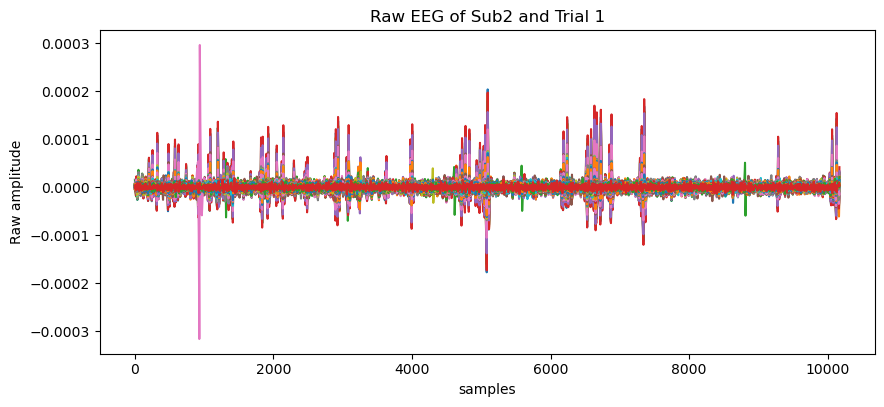

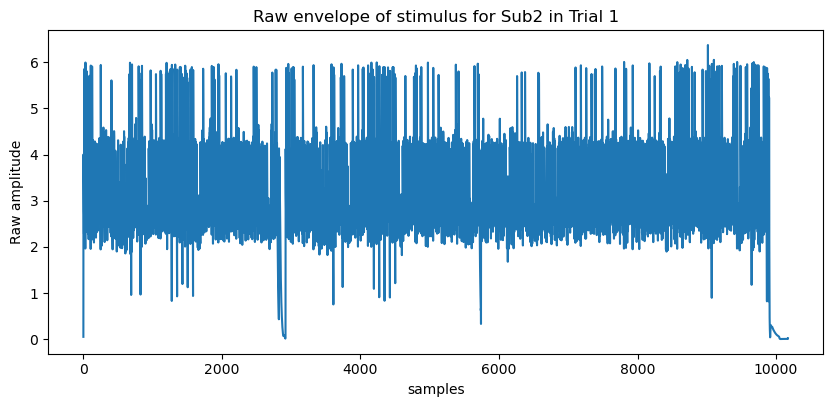

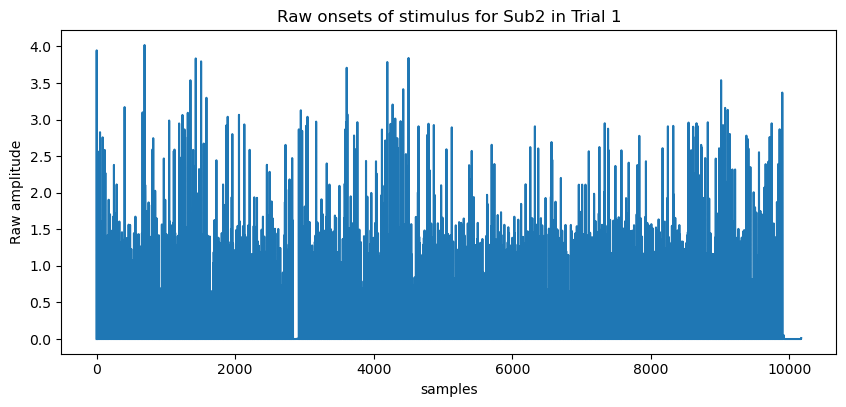

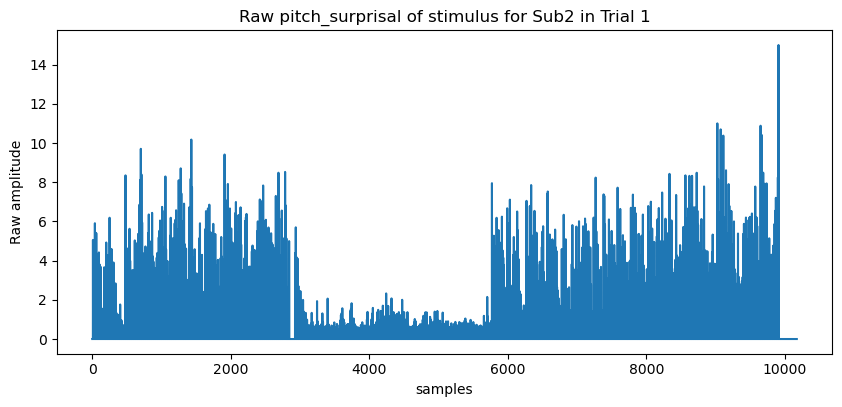

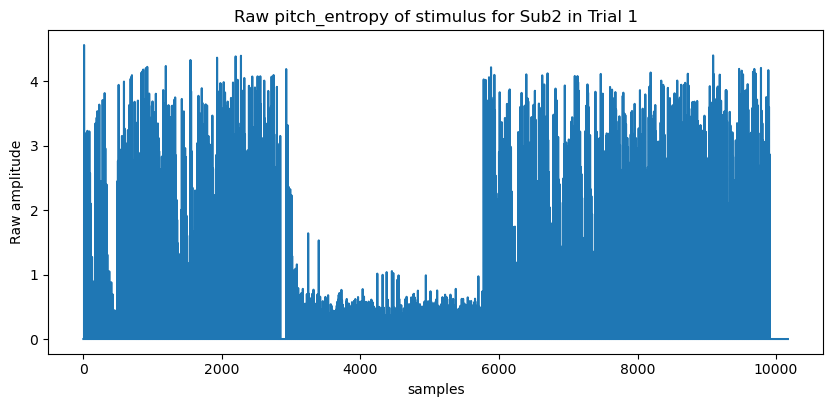

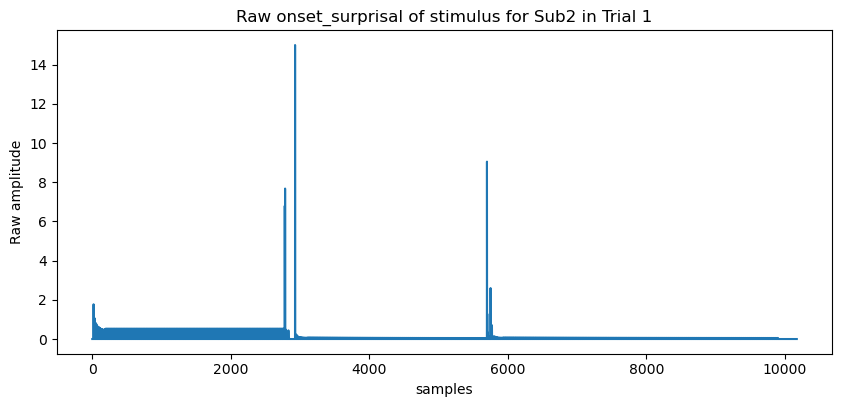

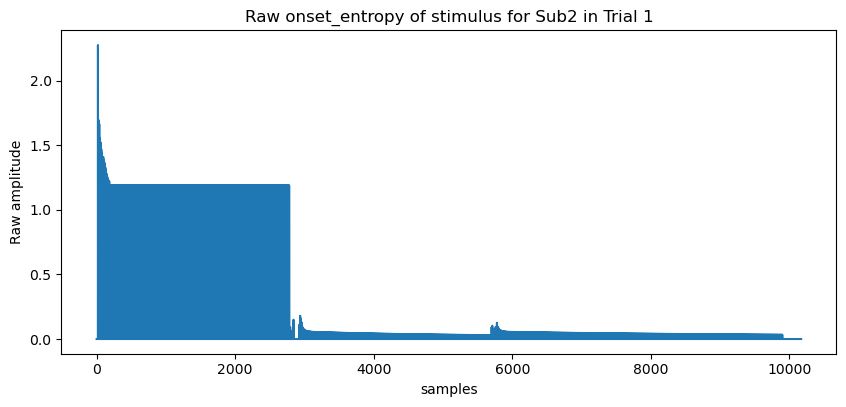

In [15]:
# ========================================
# Raw EEG & Features 
# ========================================

raw_eeg = prepared._trials_raw[trial-1]['eeg']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(raw_eeg)
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw EEG of {subject} and Trial {trial}")

# Acoustic Envelope
envelope = prepared._trials_raw[trial-1]['envelope']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(envelope)
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw envelope of stimulus for {subject} in Trial {trial}")

# Acoustic Onsets
onsets = prepared._trials_raw[trial-1]['onsets']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(onsets)
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw onsets of stimulus for {subject} in Trial {trial}")

# IDyOM Pitch Surprisal 
pitch_surprisal = prepared._trials_raw[trial-1]['pitch_surprisal']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(pitch_surprisal)
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw pitch_surprisal of stimulus for {subject} in Trial {trial}")

# IDyOM Pitch Entropy
pitch_entropy = prepared._trials_raw[trial-1]['pitch_entropy']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(pitch_entropy)
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw pitch_entropy of stimulus for {subject} in Trial {trial}")

# IDyOM Onset Surprisal
onset_surprisal = prepared._trials_raw[trial-1]['onset_surprisal']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(onset_surprisal)
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw onset_surprisal of stimulus for {subject} in Trial {trial}")

# IDyOM Onset Entropy
onset_entropy = prepared._trials_raw[trial-1]['onset_entropy']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(onset_entropy)
ax.set_xlabel('samples')
ax.set_ylabel('Raw amplitude')
ax.set_title(f"Raw onset_entropy of stimulus for {subject} in Trial {trial}")

Text(0.5, 1.0, 'Z-scored onset_entropy of stimulus for Sub2 in Trial 1')

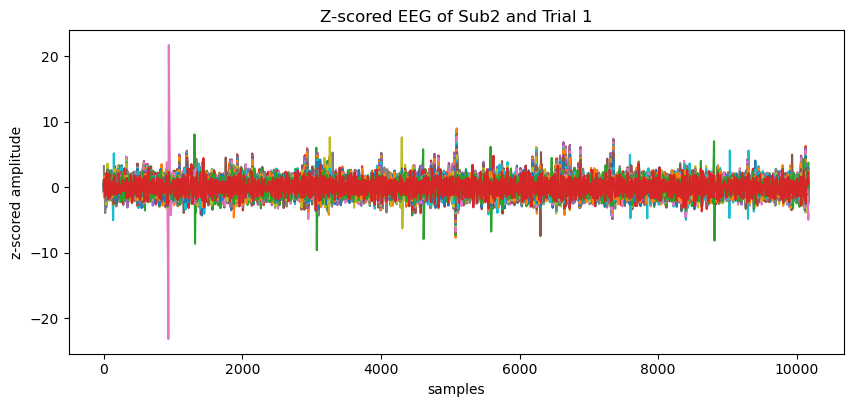

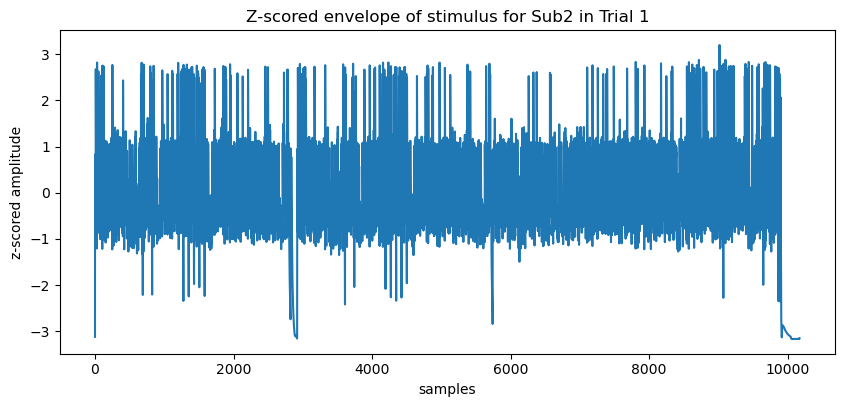

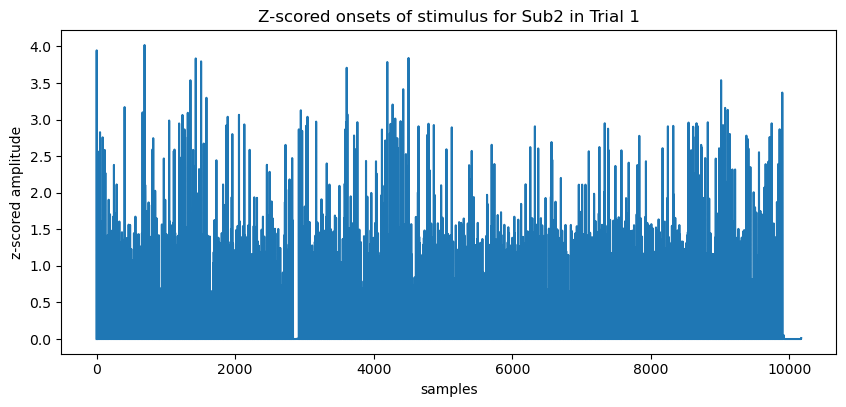

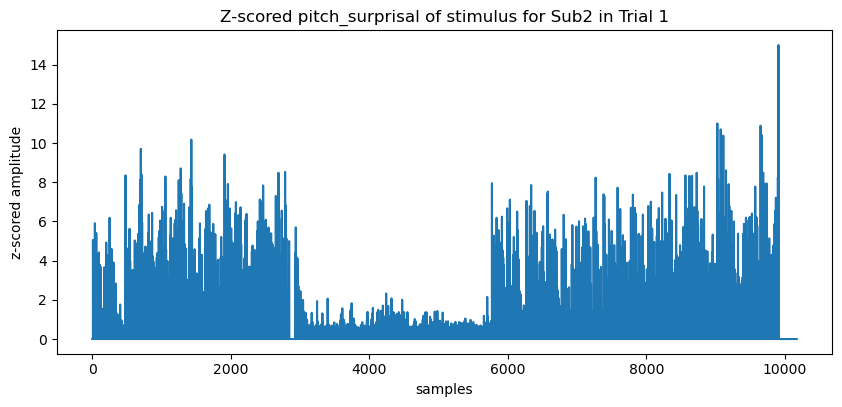

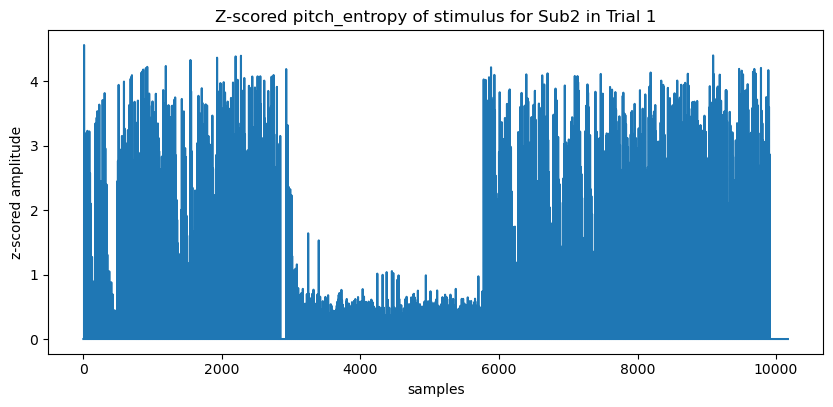

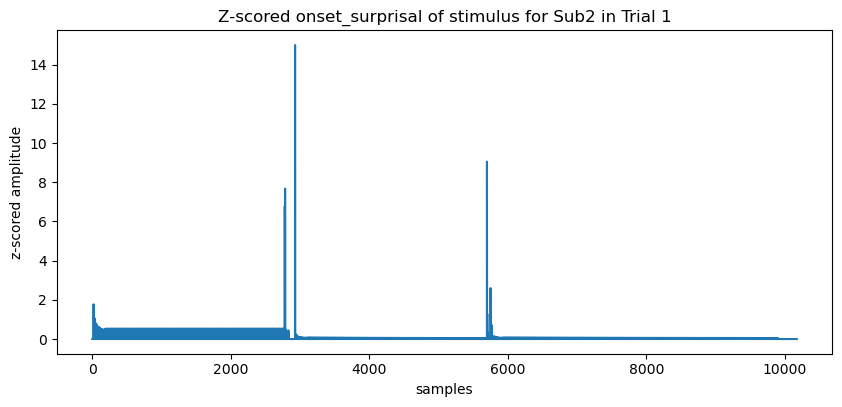

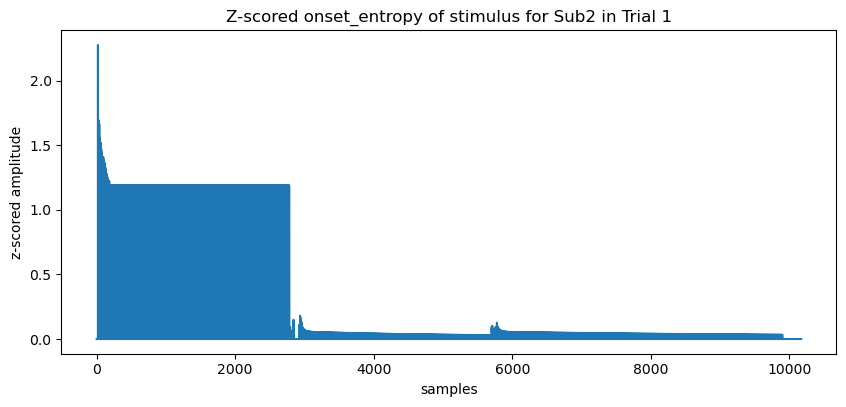

In [16]:
# ========================================
# Z-scored EEG and Features in TRFDataset
# ========================================

trial = 1

# EEG 
z_scored_eeg = acoustic_and_surprisal_ds.trials[trial-1]['eeg']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(z_scored_eeg)
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored EEG of {subject} and Trial {trial}")

# Acoustic Envelope
envelope = acoustic_and_surprisal_ds.trials[trial-1]['envelope']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(envelope)
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored envelope of stimulus for {subject} in Trial {trial}")

# Acoustic Onsets
onsets = acoustic_and_surprisal_ds.trials[trial-1]['onsets']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(onsets)
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored onsets of stimulus for {subject} in Trial {trial}")

# IDyOM Pitch Surprisal 
pitch_surprisal = acoustic_and_surprisal_ds.trials[trial-1]['pitch_surprisal']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(pitch_surprisal)
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored pitch_surprisal of stimulus for {subject} in Trial {trial}")

# IDyOM Pitch Entropy
pitch_entropy = acoustic_and_surprisal_ds.trials[trial-1]['pitch_entropy']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(pitch_entropy)
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored pitch_entropy of stimulus for {subject} in Trial {trial}")

# IDyOM Onset Surprisal
onset_surprisal = acoustic_and_surprisal_ds.trials[trial-1]['onset_surprisal']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(onset_surprisal)
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored onset_surprisal of stimulus for {subject} in Trial {trial}")

# IDyOM Onset Entropy
onset_entropy = acoustic_and_surprisal_ds.trials[trial-1]['onset_entropy']
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(onset_entropy)
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored onset_entropy of stimulus for {subject} in Trial {trial}")

# Visualize 1 datapoint for the Non Linear Model

In [17]:

from torch.utils.data import DataLoader, Subset

BATCH_SIZE     = 64   
n_trials = 30 
for i in range (n_trials):
    train_trial_ids = [j for j in range(n_trials) if j != i]
    
inner_val_trial = train_trial_ids[-1]
pure_train_trials = train_trial_ids[:-1]

val_trial = acoustic_ds.trials[inner_val_trial]

validation_eeg = val_trial['eeg']
validation_envelope = val_trial['envelope']
validation_onsets = val_trial['onsets']

train_window_idx = [w for ti in pure_train_trials for w in acoustic_ds.windows_for_trial(ti)]
val_window_idx = acoustic_ds.windows_for_trial(inner_val_trial)

train_loader = DataLoader(
        Subset(acoustic_ds, train_window_idx),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
    )
val_loader = DataLoader(
        Subset(acoustic_ds, val_window_idx),
        batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
    )

# Get one training datapoint
train_batch = next(iter(train_loader))

# Get one validation datapoint
val_batch = next(iter(val_loader))

print("Training batch:")
for x in train_batch:
    print(type(x), getattr(x, "shape", None))

print("\nValidation batch:")
for x in val_batch:
    print(type(x), getattr(x, "shape", None))

Training batch:
<class 'torch.Tensor'> torch.Size([64, 2, 448])
<class 'torch.Tensor'> torch.Size([64, 64, 448])

Validation batch:
<class 'torch.Tensor'> torch.Size([22, 2, 448])
<class 'torch.Tensor'> torch.Size([22, 64, 448])


In [18]:
# Unpack
train_acoustic, train_eeg = train_batch
val_acoustic, val_eeg = val_batch

# Take the first datapoint from each batch
train_acoustic = train_acoustic[0]   # (2, 448)
train_eeg = train_eeg[0]             # (64, 448)

val_acoustic = val_acoustic[0]       # (2, 448)
val_eeg = val_eeg[0]                 # (64, 448)

# Separate acoustic features
train_envelope = train_acoustic[0]
train_onsets = train_acoustic[1]

val_envelope = val_acoustic[0]
val_onsets = val_acoustic[1]

print("Training:")
print("  EEG:", train_eeg.shape)
print("  Envelope:", train_envelope.shape)
print("  Onsets:", train_onsets.shape)

print("\nValidation:")
print("  EEG:", val_eeg.shape)
print("  Envelope:", val_envelope.shape)
print("  Onsets:", val_onsets.shape)

Training:
  EEG: torch.Size([64, 448])
  Envelope: torch.Size([448])
  Onsets: torch.Size([448])

Validation:
  EEG: torch.Size([64, 448])
  Envelope: torch.Size([448])
  Onsets: torch.Size([448])


0.0 6.984375


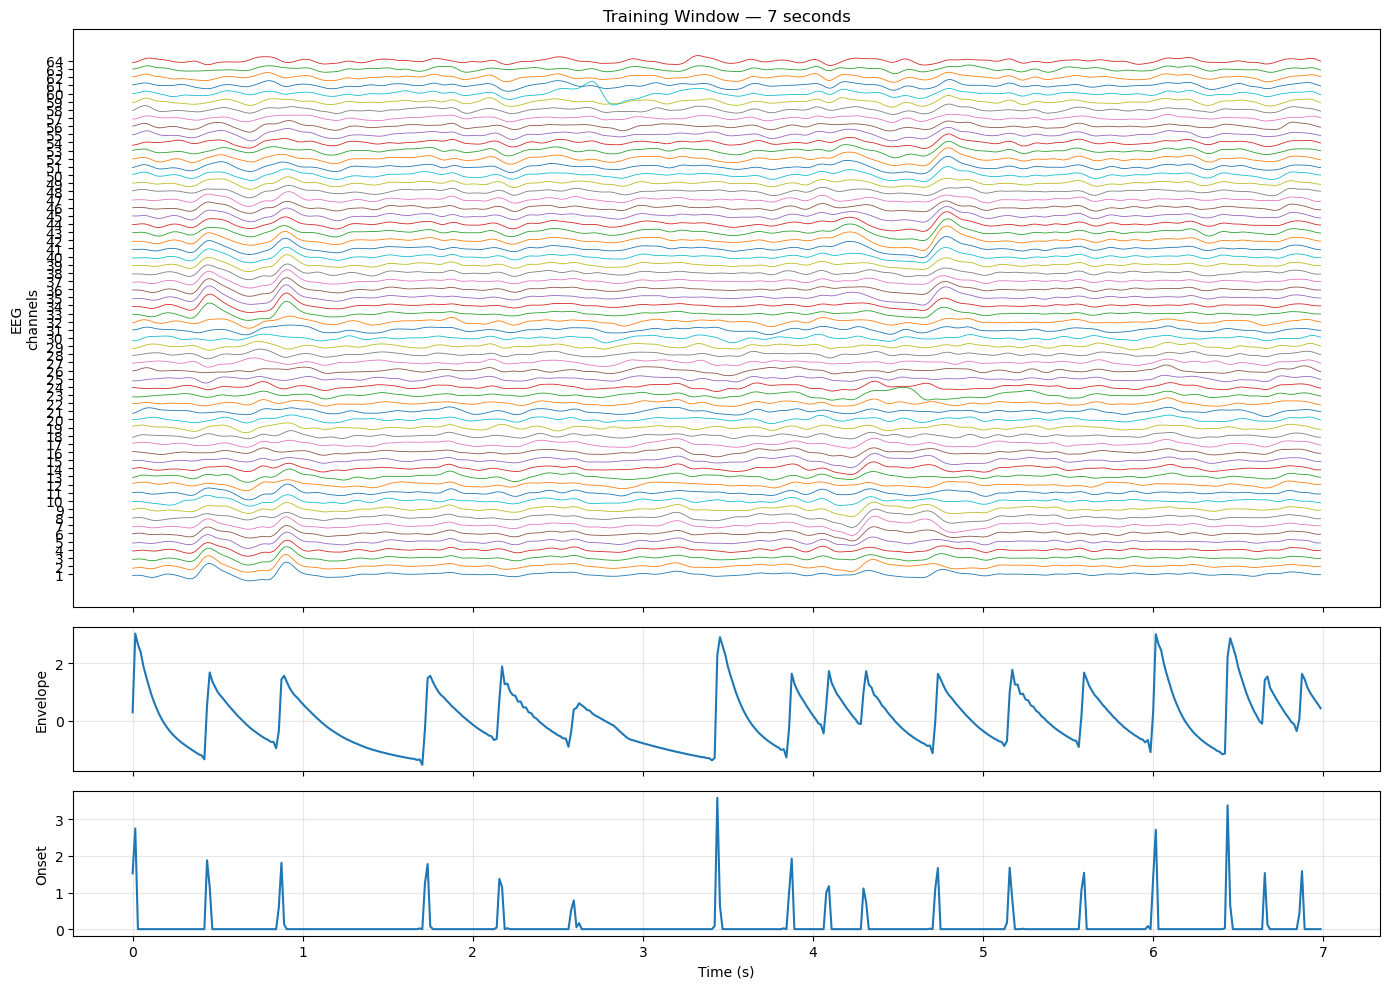

In [19]:
import numpy as np

sfreq = 64
n_samples = 448

time = np.arange(n_samples) / sfreq

print(time[0], time[-1])

import matplotlib.pyplot as plt

# Convert tensors to numpy
train_eeg_np = train_eeg.detach().cpu().numpy()
train_envelope_np = train_envelope.detach().cpu().numpy()
train_onsets_np = train_onsets.detach().cpu().numpy()

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    gridspec_kw={"height_ratios": [4, 1, 1]},
    sharex=True
)

# --------------------------------------------------
# EEG
# --------------------------------------------------

# Offset each channel vertically so they don't overlap
spacing = 5

for ch in range(64):
    axes[0].plot(
        time,
        train_eeg_np[ch] + ch * spacing,
        linewidth=0.6
    )

axes[0].set_ylabel("EEG\nchannels")
axes[0].set_title("Training Window — 7 seconds")
axes[0].set_yticks(
    np.arange(64) * spacing
)
axes[0].set_yticklabels(
    [f"{ch+1}" for ch in range(64)]
)

# --------------------------------------------------
# Envelope
# --------------------------------------------------

axes[1].plot(
    time,
    train_envelope_np
)

axes[1].set_ylabel("Envelope")
axes[1].grid(alpha=0.3)

# --------------------------------------------------
# Onsets
# --------------------------------------------------

axes[2].plot(
    time,
    train_onsets_np
)

axes[2].set_ylabel("Onset")
axes[2].set_xlabel("Time (s)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()